In [1]:
include("../RayTracing.jl")

Main.RayTracing

In [2]:
"""
std::shared_ptr<Shape> sphere = std::make_shared<Sphere>(
    &id, &id, true /* reverse orientation */, 1, -1, 1, 360);

MediumInterface mediumInterface;
std::vector<std::shared_ptr<Primitive>> prims;
prims.push_back(std::make_shared<GeometricPrimitive>(
    sphere, material, nullptr, mediumInterface));
std::shared_ptr<BVHAccel> bvh = std::make_shared<BVHAccel>(prims);

std::vector<std::shared_ptr<Light>> lights;
lights.push_back(
    std::make_shared<PointLight>(Transform(), nullptr, Spectrum(Pi)));

std::unique_ptr<Scene> scene(new Scene(bvh, lights));
"""

"std::shared_ptr<Shape> sphere = std::make_shared<Sphere>(\n    &id, &id, true /* reverse orientation */, 1, -1, 1, 360);\n\nMediumInterface mediumInterface;\nstd::vector<std::shared_ptr<Primitive>> prims;\nprims.push_back(std::make_shared<GeometricPrimitive>(\n    sphere, mate" ⋯ 19 bytes ⋯ "umInterface));\nstd::shared_ptr<BVHAccel> bvh = std::make_shared<BVHAccel>(prims);\n\nstd::vector<std::shared_ptr<Light>> lights;\nlights.push_back(\n    std::make_shared<PointLight>(Transform(), nullptr, Spectrum(Pi)));\n\nstd::unique_ptr<Scene> scene(new Scene(bvh, lights));\n"

In [3]:
function build_analytic_scene(parsed_args::Dict)::Tuple{RayTracing.AbstractIntegrator, RayTracing.Scene}
    primitives = RayTracing.Primitive[]
    lights = RayTracing.Light[]

    # materials
    mat_sphere = RayTracing.Matte(
        RayTracing.ConstantTexture(RayTracing.spectrum_from_float(0.5, 0.5, 0.5)),
        RayTracing.ConstantTexture(0.0),
        nothing
    )

    ################
    ### a sphere ###
    ################
    identity_t = RayTracing.Translate(RayTracing.Pnt3(0,0,0))
    identity_sc = RayTracing.ShapeCore(
        identity_t,
        RayTracing.Inv(identity_t),
        false,
        false
    )
    sphere = RayTracing.Sphere(identity_sc, 1.0)
    push!(primitives, RayTracing.Primitive(sphere, mat_sphere, nothing))

    # instantiate accelerator
    print("\nThere are " * RayTracing.num2str(length(primitives)) * " objects in the scene, building BVH\n")
    @time bvh = RayTracing.BVH(primitives)
    print("Done building BVH\n")

    # instantiate the infinite light
    light = RayTracing.PointLight(
        identity_t, 
        RayTracing.spectrum_from_float(Float64(pi), Float64(pi), Float64(pi))
    )
    push!(lights, light)

    # Instantiate a Filter
    filter = RayTracing.BoxFilter(RayTracing.Pnt2(.5, .5))

    # Instantiate a Film
    film = RayTracing.Film(
        RayTracing.Pnt2i(parsed_args["image-dim"][1], parsed_args["image-dim"][2]),
        RayTracing.Bounds2(RayTracing.
            RayTracing.Pnt2(parsed_args["crop-window"][1], parsed_args["crop-window"][2]), 
            RayTracing.Pnt2(parsed_args["crop-window"][3], parsed_args["crop-window"][4])
        ),
        filter,
        1.0,
        1.0,
        parsed_args["file-name"]
    )

    # Instantiate a Camera
    screen = RayTracing.Bounds2(
        RayTracing.Pnt2(-1, -1), 
        RayTracing.Pnt2(1, 1)
    )
    C = RayTracing.PerspectiveCamera(identity_t, screen, 0.0, 1.0, 0.0, 10.0, 45.0, film)

    # Instantiate a Sampler
    S = RayTracing.StratifiedSampler(parsed_args["samples-per-pixel"], parsed_args["jitter"])
    print("Using " * RayTracing.num2str(S.samples_per_pixel) * " samples per pixel\n")
    
    # Instantiate Scene
    print("There are " * RayTracing.num2str(length(lights)) * " lights in the scene\n")
    scene = RayTracing.Scene(lights, bvh)
    
    # Instantiate an Integrator
    I = RayTracing.BDPTIntegrator(C, S, parsed_args["max-depth"])
    return I, scene
end

build_analytic_scene (generic function with 1 method)


There are 1 objects in the scene, building BVH
  0.000141 seconds (10 allocations: 672 bytes)
Done building BVH
Film - cropped_pixel_bounds: Main.RayTracing.Bounds2i([0, 0], [18, 18])
Film - number of pixels: 324
Using 1 samples per pixel
There are 1 lights in the scene
Sample Bounds: Main.RayTracing.Bounds2i([0, 0], [18, 18])
Tile: [0, 0] - 2 x 2
Tile Bounds: Main.RayTracing.Bounds2i([0, 0], [15, 15])
Working on pixel: [0, 0]
	pFilm: [0.5, 0.5]
	added L: [0.9598406611868654, 0.9598406611868654, 0.9598406611868654]
Working on pixel: [1, 0]
	pFilm: [1.5, 0.5]
	added L: [0.958884241014554, 0.958884241014554, 0.958884241014554]
Working on pixel: [2, 0]
	pFilm: [2.5, 0.5]
	added L: [0.9579955881394053, 0.9579955881394053, 0.9579955881394053]
Working on pixel: [3, 0]
	pFilm: [3.5, 0.5]
	added L: [0.9571922640342183, 0.9571922640342183, 0.9571922640342183]
Working on pixel: [4, 0]
	pFilm: [4.5, 0.5]
	added L: [0.9564913848170629, 0.9564913848170629, 0.9564913848170629]
Working on pixel: [5,

Progress:  50%|████████████████████▌                    |  ETA: 0:00:00

Tile: [0, 1] - 2 x 2
Tile Bounds: Main.RayTracing.Bounds2i([0, 16], [15, 18])
Working on pixel: [0, 16]
	pFilm: [0.5, 16.5]
	added L: [0.958884241014554, 0.958884241014554, 0.958884241014554]
Working on pixel: [1, 16]
	pFilm: [1.5, 16.5]
	added L: [0.9578644503478144, 0.9578644503478144, 0.9578644503478144]
Working on pixel: [2, 16]
	pFilm: [2.5, 16.5]
	added L: [0.9569154496693264, 0.9569154496693264, 0.9569154496693264]
Working on pixel: [3, 16]
	pFilm: [3.5, 16.5]
	added L: [0.9560563690411811, 0.9560563690411811, 0.9560563690411811]
Working on pixel: [4, 16]
	pFilm: [4.5, 16.5]
	added L: [0.9553059191812191, 0.9553059191812191, 0.9553059191812191]
Working on pixel: [5, 16]
	pFilm: [5.5, 16.5]
	added L: [0.9546815463533133, 0.9546815463533133, 0.9546815463533133]
Working on pixel: [6, 16]
	pFilm: [6.5, 16.5]
	added L: [0.9541985594817751, 0.9541985594817751, 0.9541985594817751]
Working on pixel: [7, 16]
	pFilm: [7.5, 16.5]
	added L: [0.9538693008371593, 0.9538693008371593, 0.9538693

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


merge_pixel: Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0)))
	pixel: [12, 16]
tile_pixel: Main.RayTracing.FilmTilePixel([1.9088801058350884, 1.9088801058350884, 1.9088801058350884], 2.0)
merge_pixel: Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0)))
	pixel: [13, 16]
tile_pixel: Main.RayTracing.FilmTilePixel([1.9099874655345324, 1.9099874655345324, 1.9099874655345324], 2.0)
merge_pixel: Main.RayTracing.Pixel([0.0, 0.0, 0.0], 0.0, Main.RayTracing.AtomicXYZPBRT(Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0), Base.Threads.Atomic{Float64}(0.0)))
	pixel: [14, 16]
tile_pixel: Main.RayTracing.FilmTilePixel([1.9113622882224002, 1.9113622882224002, 1.9113622882224002], 2.0)
merge_pixel: Main.RayTracing.Pixel([0.0, 0.

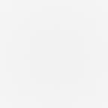

In [7]:
parsed_args = RayTracing.parse_commandline()
parsed_args["image-dim"] = [18,18]
parsed_args["samples-per-pixel"] = 1
parsed_args["jitter"] = false

logger = RayTracing.setup_logging(parsed_args["debug"])
RayTracing.global_logger(logger)

# set random seed
RayTracing.Random.seed!(parsed_args["seed"])

I, scene = build_analytic_scene(parsed_args)

image = RayTracing.render(
    I, 
    scene, 
    parsed_args,
    (-1, -1)
)

In [8]:
size(image)

(18, 18)